In [1]:
import os
from pathlib import Path

# Get the current directory of the notebook
notebook_path = Path.cwd()

ROOT = notebook_path.parent.parent

# Change the Working Directory for the whole process
os.chdir(ROOT)

print(f"Current Working Directory fixed to: {os.getcwd()}")

Current Working Directory fixed to: /srv/homes/onbo10/thesis_main


In [2]:
from src.Geometry.triangulation.triangulator import Triangulator
import cv2
from src.Geometry.triangulation.triangulation_utils import *
from utilities.visualizer import TriangulationVisualizer

Reconstructing vid_000001_left_frame_000027...
Success! Reconstructed 24209 points.


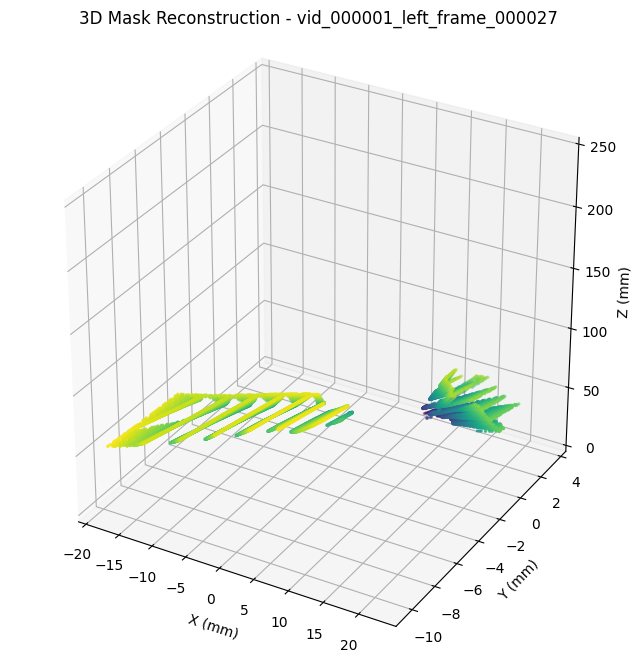

In [3]:

# 1. Setup paths

left_mask_path = "data/Surgpose_for_segmentation/left_test_set/binary_masks/vid_000001_left_frame_000027.png"
frame_id= os.path.basename(left_mask_path).split('.')[0]
right_mask_path = left_mask_path.replace('left', 'right')
zip_calib_path = "data/SurgPose/SurgPose_for_HRNet/000001.zip"

# 2. Initialize Tools
triangulator = Triangulator()
triangulator.load_calibration(zip_calib_path)
visualizer = TriangulationVisualizer()

# 3. Load Masks
mask_l = cv2.imread(left_mask_path, cv2.IMREAD_GRAYSCALE)
mask_r = cv2.imread(right_mask_path, cv2.IMREAD_GRAYSCALE)

# 4. Run Reconstruction
# We use a sampling_rate of 20 to keep the plot responsive
print(f"Reconstructing {frame_id}...")
points_3d_cloud = triangulator.reconstruct_mask_3d(mask_l, mask_r, sampling_rate=5)

# 5. Visualize
if points_3d_cloud.size > 0:
    print(f"Success! Reconstructed {len(points_3d_cloud)} points.")
    visualizer.plot_3d_mask(points_3d_cloud, frame_id, show=True)
else:
    print("Reconstruction failed: No matching pixels found along epipolar lines.")